# Loss Functions Lab — MSE, MAE, Binary Cross-Entropy, Categorical Cross-Entropy

**Duration:** 80 minutes
**Prerequisite:** Theory/math for MSE, MAE, and
Cross-Entropy loss in lecture. This lab is purely applied — translating those
formulas into PyTorch and seeing how each loss behaves on real data.

### Learning Objectives
- Translate the MSE and MAE formulas into PyTorch (manual + `torch.nn`) and see how each responds to outliers.
- Implement `nn.BCEWithLogitsLoss` for binary classification, understanding the raw-logits convention.
- Implement `nn.CrossEntropyLoss` for multi-class classification, and see how it generalizes the binary case.

### Roadmap
1. MSE & MAE — California Housing (regression)
2. Binary Cross-Entropy — Breast Cancer (binary classification)
3. Categorical Cross-Entropy — Digits (multi-class classification)
4. Exercises


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_breast_cancer, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. MSE & MAE — California Housing

### 1.1 Dataset Exploration

We subsample California Housing down to 400 rows and use a single feature
(`MedInc`, median income) to predict `MedHouseVal`, so the loss landscape and
outlier effects stay visually simple. We then inject 3 synthetic outliers
into the target so we can compare how MSE and MAE react to them.

In [ ]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.shape

(20640, 9)

In [ ]:
# Subsample to keep the loss landscape / outlier demo visually clean
df_sub = df.sample(n=400, random_state=42).reset_index(drop=True)

# Use a single feature for easy 1D visualization
X_reg = df_sub[["MedInc"]].values.astype(np.float32)     # [N, 1]
y_reg = df_sub["MedHouseVal"].values.astype(np.float32)  # [N]

# Inject 3 synthetic outliers into the target
outlier_idx = [5, 120, 300]
y_reg_outliers = y_reg.copy()
y_reg_outliers[outlier_idx] += 20.0  # push these targets far away

print("X_reg shape:", X_reg.shape)   # [N, 1]
print("y_reg shape:", y_reg.shape)   # [N]

X_reg_t = torch.tensor(X_reg)             # [N, 1]
y_clean_t = torch.tensor(y_reg)           # [N]
y_outlier_t = torch.tensor(y_reg_outliers)  # [N]

X_reg shape: (400, 1)
y_reg shape: (400,)


### 1.2 Mean Squared Error

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2$$

In [ ]:
def mse_manual(y_true, y_pred):
    return torch.mean((y_true - y_pred) ** 2)

# sanity check against nn.MSELoss on dummy predictions
y_true_demo = torch.tensor([3.0, -0.5, 2.0, 7.0])
y_pred_demo = torch.tensor([2.5, 0.0, 2.0, 8.0])

mse_manual_val = mse_manual(y_true_demo, y_pred_demo)
mse_nn_val = nn.MSELoss()(y_pred_demo, y_true_demo)

print(f"Manual MSE:  {mse_manual_val.item():.4f}")
print(f"nn.MSELoss:  {mse_nn_val.item():.4f}")
assert torch.allclose(mse_manual_val, mse_nn_val)

Manual MSE:  0.3750
nn.MSELoss:  0.3750


### 1.3 Mean Absolute Error

$$\text{MAE} = \frac{1}{N}\sum_{i=1}^{N}|y_i - \hat{y}_i|$$

In [ ]:
def mae_manual(y_true, y_pred):
    return torch.mean(torch.abs(y_true - y_pred))

mae_manual_val = mae_manual(y_true_demo, y_pred_demo)
mae_nn_val = nn.L1Loss()(y_pred_demo, y_true_demo)

print(f"Manual MAE:  {mae_manual_val.item():.4f}")
print(f"nn.L1Loss:   {mae_nn_val.item():.4f}")
assert torch.allclose(mae_manual_val, mae_nn_val)

Manual MAE:  0.5000
nn.L1Loss:   0.5000


### 1.4 Both Losses on the Same Predictions

A single linear layer stands in for $\hat{y} = Wx + b$. We compare MSE vs.
MAE on the *same* predictions, once against clean targets and once against
outlier-contaminated targets.

In [ ]:
class LinearRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)  # W, b

    def forward(self, x):                  # x: [N, 1]
        return self.linear(x).squeeze(1)   # [N]

torch.manual_seed(42)
model_demo = LinearRegressor()
preds_demo = model_demo(X_reg_t)  # [N]

print("Predictions vs. clean targets:")
print("  MSE:", nn.MSELoss()(preds_demo, y_clean_t).item())
print("  MAE:", nn.L1Loss()(preds_demo, y_clean_t).item())

print("Predictions vs. outlier-contaminated targets:")
print("  MSE:", nn.MSELoss()(preds_demo, y_outlier_t).item())
print("  MAE:", nn.L1Loss()(preds_demo, y_outlier_t).item())

Predictions vs. clean targets:
  MSE: 4.48304557800293
  MAE: 1.8150527477264404
Predictions vs. outlier-contaminated targets:
  MSE: 6.977007865905762
  MAE: 1.9397510290145874


### 1.5 Visualization — Loss Landscape & Training Curves

We sweep a single weight (bias fixed at 0) and plot MSE and MAE as a
function of that weight, with and without outliers.

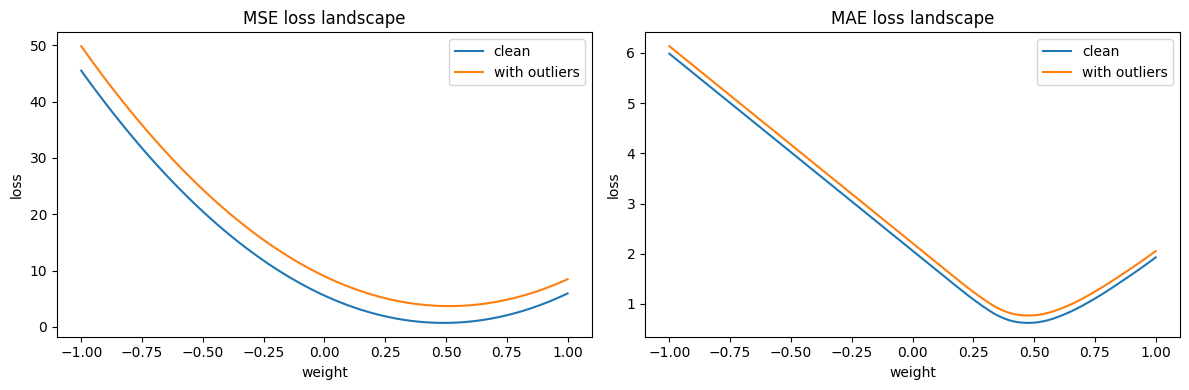

In [ ]:
weights = np.linspace(-1, 1, 100)
bias_fixed = 0.0

def sweep_loss(loss_fn, X, y, weights, bias):
    losses = []
    for w in weights:
        preds = w * X.squeeze() + bias  # [N]
        preds_t = torch.tensor(preds, dtype=torch.float32)
        losses.append(loss_fn(preds_t, torch.tensor(y, dtype=torch.float32)).item())
    return np.array(losses)

mse_clean = sweep_loss(nn.MSELoss(), X_reg, y_reg, weights, bias_fixed)
mse_out = sweep_loss(nn.MSELoss(), X_reg, y_reg_outliers, weights, bias_fixed)
mae_clean = sweep_loss(nn.L1Loss(), X_reg, y_reg, weights, bias_fixed)
mae_out = sweep_loss(nn.L1Loss(), X_reg, y_reg_outliers, weights, bias_fixed)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(weights, mse_clean, label="clean")
axes[0].plot(weights, mse_out, label="with outliers")
axes[0].set_title("MSE loss landscape")
axes[0].set_xlabel("weight"); axes[0].set_ylabel("loss"); axes[0].legend()

axes[1].plot(weights, mae_clean, label="clean")
axes[1].plot(weights, mae_out, label="with outliers")
axes[1].set_title("MAE loss landscape")
axes[1].set_xlabel("weight"); axes[1].set_ylabel("loss"); axes[1].legend()

plt.tight_layout()
plt.show()

**Notice:** the outliers shift and sharpen the MSE curve far more than
the MAE curve — MSE's quadratic penalty makes large residuals dominate the
loss, while MAE's linear penalty keeps it comparatively stable.

Now let's actually *train* two regressors on the outlier-contaminated data —
one with MSE, one with MAE — and compare.

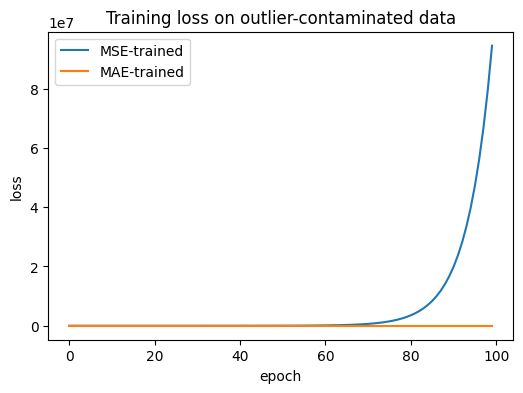

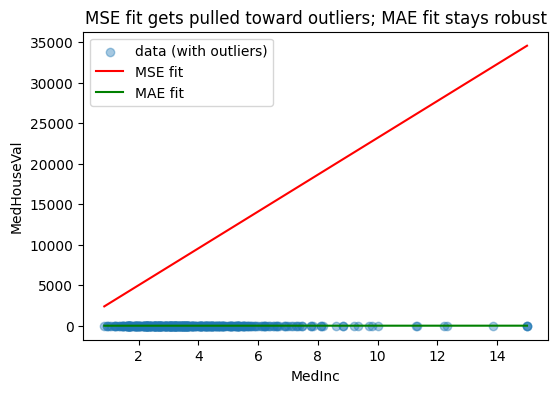

In [ ]:
def train_regressor(loss_fn, X, y, epochs=100, lr=0.05):
    torch.manual_seed(42)
    model = LinearRegressor()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(X)          # [N]
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return model, losses

model_mse, losses_mse = train_regressor(nn.MSELoss(), X_reg_t, y_outlier_t)
model_mae, losses_mae = train_regressor(nn.L1Loss(), X_reg_t, y_outlier_t)

plt.figure(figsize=(6, 4))
plt.plot(losses_mse, label="MSE-trained")
plt.plot(losses_mae, label="MAE-trained")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Training loss on outlier-contaminated data")
plt.legend()
plt.show()

xs = np.linspace(X_reg.min(), X_reg.max(), 50).reshape(-1, 1).astype(np.float32)
xs_t = torch.tensor(xs)

plt.figure(figsize=(6, 4))
plt.scatter(X_reg, y_reg_outliers, alpha=0.4, label="data (with outliers)")
plt.plot(xs, model_mse(xs_t).detach().numpy(), color="red", label="MSE fit")
plt.plot(xs, model_mae(xs_t).detach().numpy(), color="green", label="MAE fit")
plt.xlabel("MedInc"); plt.ylabel("MedHouseVal"); plt.legend()
plt.title("MSE fit gets pulled toward outliers; MAE fit stays robust")
plt.show()

## 2. Binary Cross-Entropy — Breast Cancer

### 2.1 Dataset Exploration

In [ ]:
bc = load_breast_cancer()
X_bc = bc.data.astype(np.float32)      # [N, 30]
y_bc = bc.target.astype(np.float32)    # [N], 0 = malignant, 1 = benign

print("X_bc shape:", X_bc.shape)       # [N, 30]
print("y_bc shape:", y_bc.shape)       # [N]
print("Class balance (0=malignant, 1=benign):", np.bincount(y_bc.astype(int)))

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

scaler_bc = StandardScaler()
X_train_bc = scaler_bc.fit_transform(X_train_bc).astype(np.float32)
X_test_bc = scaler_bc.transform(X_test_bc).astype(np.float32)

X_train_bc_t = torch.tensor(X_train_bc)  # [N_train, 30]
y_train_bc_t = torch.tensor(y_train_bc)  # [N_train]
X_test_bc_t = torch.tensor(X_test_bc)    # [N_test, 30]
y_test_bc_t = torch.tensor(y_test_bc)    # [N_test]

X_bc shape: (569, 30)
y_bc shape: (569,)
Class balance (0=malignant, 1=benign): [212 357]


### 2.2 Binary Cross-Entropy

$$\text{BCE} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right], \qquad \hat{p}_i = \sigma(z_i)$$

`nn.BCEWithLogitsLoss` takes the **raw logit** $z_i$ and applies the sigmoid
internally (in a numerically stable way) — you should never pre-apply
`sigmoid` before passing predictions to it.

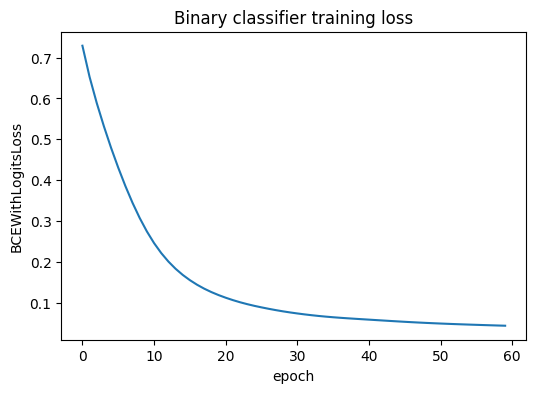

In [ ]:
class BinaryClassifier(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):               # x: [N, 30]
        return self.net(x).squeeze(1)   # [N] raw logits (no sigmoid!)

torch.manual_seed(42)
model_bc = BinaryClassifier(in_features=X_train_bc.shape[1])
criterion_bc = nn.BCEWithLogitsLoss()
optimizer_bc = torch.optim.Adam(model_bc.parameters(), lr=0.01)

epochs_bc = 60
losses_bc = []
for epoch in range(epochs_bc):
    optimizer_bc.zero_grad()
    logits = model_bc(X_train_bc_t)        # [N_train] raw logits
    loss = criterion_bc(logits, y_train_bc_t)
    loss.backward()
    optimizer_bc.step()
    losses_bc.append(loss.item())

plt.figure(figsize=(6, 4))
plt.plot(losses_bc)
plt.xlabel("epoch"); plt.ylabel("BCEWithLogitsLoss")
plt.title("Binary classifier training loss")
plt.show()

### 2.3 The Logits-vs-Probabilities Pitfall

`BCEWithLogitsLoss` fuses `sigmoid` + `BCELoss` internally for numerical
stability. If you pre-apply `sigmoid` yourself and *then* pass the result
in, you're silently squashing twice — the loss value (and gradients) become
wrong.

In [ ]:
with torch.no_grad():
    test_logits = model_bc(X_test_bc_t[:5])         # [5] raw logits
    test_probs_wrong = torch.sigmoid(test_logits)    # already-squashed probs

# Correct usage: pass raw logits directly
loss_correct = criterion_bc(test_logits, y_test_bc_t[:5])
# Incorrect usage: pass already-sigmoided probabilities
loss_wrong = criterion_bc(test_probs_wrong, y_test_bc_t[:5])

print(f"Loss with raw logits (correct):          {loss_correct.item():.4f}")
print(f"Loss with pre-sigmoided probs (WRONG):    {loss_wrong.item():.4f}")

Loss with raw logits (correct):          0.2225
Loss with pre-sigmoided probs (WRONG):    0.5871


### 2.4 Visualization — Per-Sample Loss

We compute the *per-sample* BCE loss (no reduction) on the test set and
compare the lowest-loss (confident & correct) samples against the
highest-loss (wrong / unsure) samples.

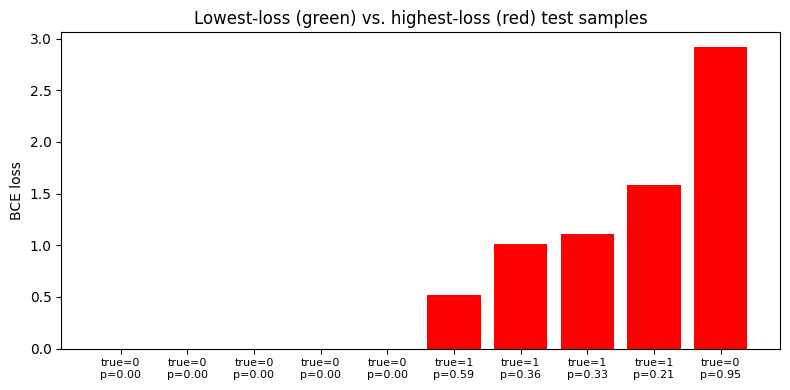

In [ ]:
with torch.no_grad():
    test_logits_all = model_bc(X_test_bc_t)  # [N_test]
    per_sample_loss = nn.BCEWithLogitsLoss(reduction="none")(test_logits_all, y_test_bc_t)  # [N_test]
    probs_bc = torch.sigmoid(test_logits_all)  # [N_test]

sorted_idx = torch.argsort(per_sample_loss)
low_loss_idx = sorted_idx[:5]    # confident & correct
high_loss_idx = sorted_idx[-5:]  # highest loss

idx_show_bc = torch.cat([low_loss_idx, high_loss_idx])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(idx_show_bc)), per_sample_loss[idx_show_bc].numpy(),
       color=["green"] * 5 + ["red"] * 5)
ax.set_xticks(range(len(idx_show_bc)))
ax.set_xticklabels(
    [f"true={int(y_test_bc_t[i].item())}\np={probs_bc[i].item():.2f}" for i in idx_show_bc],
    fontsize=8,
)
ax.set_ylabel("BCE loss")
ax.set_title("Lowest-loss (green) vs. highest-loss (red) test samples")
plt.tight_layout()
plt.show()

## 3. Categorical Cross-Entropy — Digits

### 3.1 Dataset Exploration

X_dig shape: (1797, 64)
y_dig shape: (1797,)


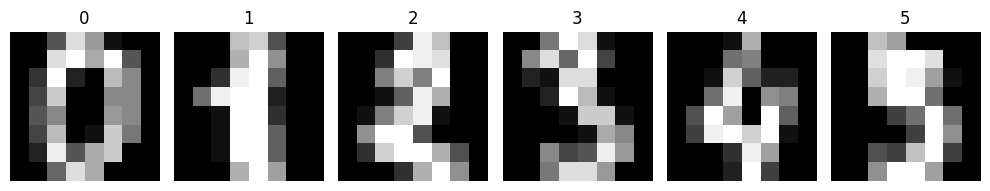

In [ ]:
digits = load_digits()
X_dig = digits.data.astype(np.float32)   # [N, 64]
y_dig = digits.target.astype(np.int64)   # [N], classes 0-9

print("X_dig shape:", X_dig.shape)  # [N, 64]
print("y_dig shape:", y_dig.shape)  # [N]

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(str(digits.target[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dig, y_dig, test_size=0.2, random_state=42, stratify=y_dig
)

scaler_d = StandardScaler()
X_train_d = scaler_d.fit_transform(X_train_d).astype(np.float32)
X_test_d = scaler_d.transform(X_test_d).astype(np.float32)

X_train_d_t = torch.tensor(X_train_d)  # [N_train, 64]
y_train_d_t = torch.tensor(y_train_d)  # [N_train] int64 class ids
X_test_d_t = torch.tensor(X_test_d)    # [N_test, 64]
y_test_d_t = torch.tensor(y_test_d)    # [N_test]

### 3.2 Categorical Cross-Entropy

$$\text{CE} = -\frac{1}{N}\sum_{i=1}^{N} \log\left(\frac{e^{z_{i,y_i}}}{\sum_{k=1}^{K} e^{z_{i,k}}}\right)$$

`nn.CrossEntropyLoss` takes **raw logits** of shape `[N, K]` and **integer
class indices** of shape `[N]` (a `LongTensor`, *not* one-hot). Internally it
applies `log_softmax` + `nll_loss` — same "don't pre-squash" rule as
`BCEWithLogitsLoss`, but with `softmax` (over `K` classes) instead of
`sigmoid` (over 1 logit).

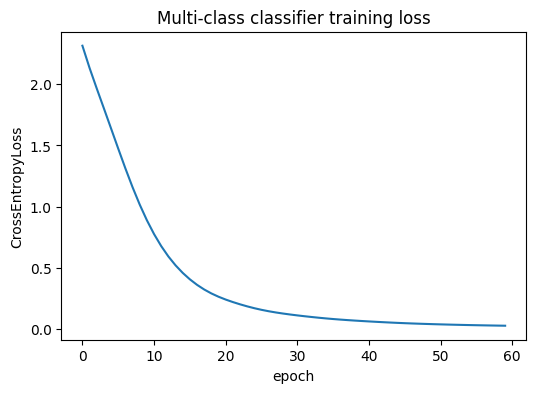

In [ ]:
class MultiClassifier(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):        # x: [N, 64]
        return self.net(x)       # [N, 10] raw logits (no softmax!)

torch.manual_seed(42)
model_dig = MultiClassifier(in_features=X_train_d.shape[1], num_classes=10)
criterion_dig = nn.CrossEntropyLoss()
optimizer_dig = torch.optim.Adam(model_dig.parameters(), lr=0.01)

epochs_dig = 60
losses_dig = []
for epoch in range(epochs_dig):
    optimizer_dig.zero_grad()
    logits = model_dig(X_train_d_t)             # [N_train, 10]
    loss = criterion_dig(logits, y_train_d_t)   # y_train_d_t: [N_train] int64
    loss.backward()
    optimizer_dig.step()
    losses_dig.append(loss.item())

plt.figure(figsize=(6, 4))
plt.plot(losses_dig)
plt.xlabel("epoch"); plt.ylabel("CrossEntropyLoss")
plt.title("Multi-class classifier training loss")
plt.show()

**Binary vs. multi-class, side by side:** binary squashes a single
logit through `sigmoid` into one probability; multi-class squashes `K`
logits through `softmax` into a distribution over `K` classes that sums to
1.

In [ ]:
with torch.no_grad():
    sample_logits = model_dig(X_test_d_t[:1])           # [1, 10]
    sample_probs = torch.softmax(sample_logits, dim=1)  # [1, 10], sums to 1

print("Raw logits:   ", sample_logits.numpy().round(2))
print("Softmax probs:", sample_probs.numpy().round(2))
print("Sum of probs: ", sample_probs.sum().item())

Raw logits:    [[ -3.65  -4.85  -9.32  -3.01  -5.6    6.17  -4.21 -10.33  -0.22   4.72]]
Softmax probs: [[0.   0.   0.   0.   0.   0.81 0.   0.   0.   0.19]]
Sum of probs:  0.9999999403953552


### 3.3 Visualization — Per-Sample Loss (Binary vs. Multi-Class)

Same idea as Section 2.4, now for the 10-class digit classifier — plotted
next to the binary case to see the same "confidence penalty" pattern show
up in both settings.

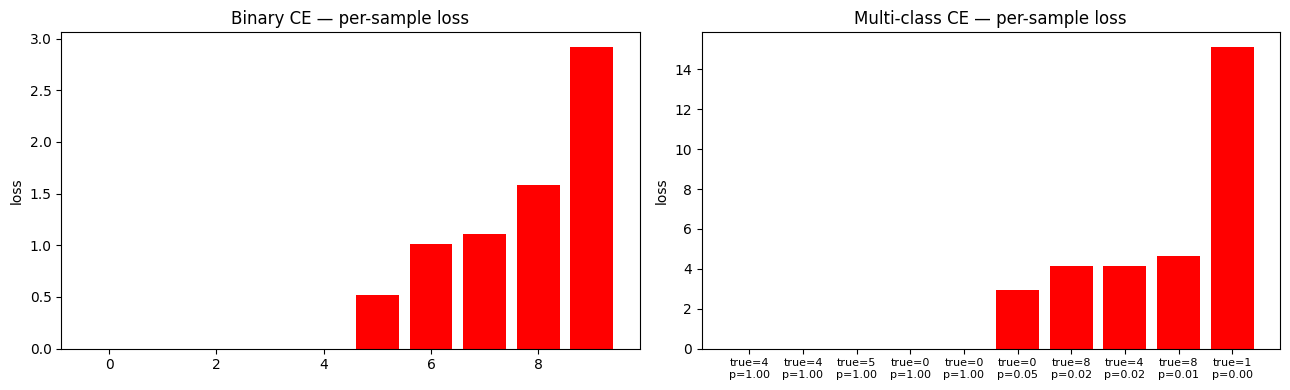

In [ ]:
with torch.no_grad():
    test_logits_dig = model_dig(X_test_d_t)  # [N_test, 10]
    per_sample_loss_dig = nn.CrossEntropyLoss(reduction="none")(test_logits_dig, y_test_d_t)  # [N_test]
    pred_probs_dig = torch.softmax(test_logits_dig, dim=1)  # [N_test, 10]
    confidence_dig = pred_probs_dig.gather(1, y_test_d_t.unsqueeze(1)).squeeze(1)  # [N_test]

sorted_idx_dig = torch.argsort(per_sample_loss_dig)
low_idx_dig = sorted_idx_dig[:5]
high_idx_dig = sorted_idx_dig[-5:]
idx_show_dig = torch.cat([low_idx_dig, high_idx_dig])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(len(idx_show_bc)), per_sample_loss[idx_show_bc].numpy(),
            color=["green"] * 5 + ["red"] * 5)
axes[0].set_title("Binary CE — per-sample loss")
axes[0].set_ylabel("loss")

axes[1].bar(range(len(idx_show_dig)), per_sample_loss_dig[idx_show_dig].numpy(),
            color=["green"] * 5 + ["red"] * 5)
axes[1].set_xticks(range(len(idx_show_dig)))
axes[1].set_xticklabels(
    [f"true={int(y_test_d_t[i].item())}\np={confidence_dig[i].item():.2f}" for i in idx_show_dig],
    fontsize=8,
)
axes[1].set_title("Multi-class CE — per-sample loss")
axes[1].set_ylabel("loss")

plt.tight_layout()
plt.show()

## 4. Student Exercises

### Exercise 1 — MSE → MAE on Outlier-Contaminated Housing Data

The regressor below is trained with **MSE** on the same
outlier-contaminated housing targets (`y_reg_outliers`) from Section 1.

**TODO:**
1. Change the loss function from `nn.MSELoss()` to the correct alternative.
2. Re-run and compare the fitted line against the MSE-trained line (plotted
   in red as a reference) — is it pulled toward the outliers less?

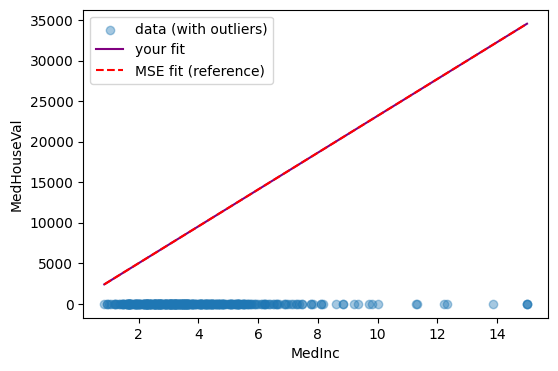

In [ ]:
def train_regressor_exercise(loss_fn, X, y, epochs=100, lr=0.05):
    torch.manual_seed(42)
    model = LinearRegressor()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(X)
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return model, losses

# TODO: replace nn.MSELoss() with the loss function that is more robust to outliers
exercise_loss_fn = nn.MSELoss()  # <-- CHANGE THIS

model_exercise, losses_exercise = train_regressor_exercise(
    exercise_loss_fn, X_reg_t, y_outlier_t
)

plt.figure(figsize=(6, 4))
plt.scatter(X_reg, y_reg_outliers, alpha=0.4, label="data (with outliers)")
plt.plot(xs, model_exercise(xs_t).detach().numpy(), color="purple", label="your fit")
plt.plot(xs, model_mse(xs_t).detach().numpy(), color="red", linestyle="--", label="MSE fit (reference)")
plt.xlabel("MedInc"); plt.ylabel("MedHouseVal"); plt.legend()
plt.show()

<details>
<summary>Click to reveal solution</summary>

```python
exercise_loss_fn = nn.L1Loss()
```

Re-running the training loop with `nn.L1Loss()` produces a fitted line much
closer to the bulk of the (non-outlier) data, since MAE's gradient
magnitude doesn't grow with the size of the residual the way MSE's does —
each outlier contributes a constant-magnitude pull instead of a pull
proportional to its distance from the line.
</details>

## 5. Recap

| Loss | PyTorch class | Input format | Use case | Key property |
|---|---|---|---|---|
| MSE | `nn.MSELoss` | raw predictions | regression | quadratic penalty — outlier-sensitive |
| MAE | `nn.L1Loss` | raw predictions | regression | linear penalty — robust to outliers |
| Binary CE | `nn.BCEWithLogitsLoss` | raw single logit `[N]` | binary classification | applies `sigmoid` internally — never pre-sigmoid your inputs |
| Categorical CE | `nn.CrossEntropyLoss` | raw `K` logits `[N, K]` | multi-class classification | applies `log_softmax` internally — targets are class indices (`LongTensor`), not one-hot |
